# **Ujjwal Karki: Fake News Detector**

## 1. Import Libraries


In [1]:
from pathlib import Path
from wordcloud import WordCloud
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## 2. Load the Dataset

In [2]:
DATA_PATH = Path("data") / "news.csv"

df_raw = pd.read_csv(DATA_PATH)

# dataset contains 'unamed' index column, renaming it to 'source_index' for clarity
if df_raw.columns[0].startswith("Unnamed"):
    df_raw = df_raw.rename(columns={df_raw.columns[0]: "source_index"})

print(f"Dataset path: {DATA_PATH}")
print(f"Rows, Columns: {df_raw.shape}")
display(df_raw.head())

Dataset path: data\news.csv
Rows, Columns: (6335, 4)


,source_index,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


## 3. Initial Data Overview

### *3.1. Data Information*

In [3]:
print("--------------------------------------------------------------")
print(f"Columns and Data Types:")
print("--------------------------------------------------------------")
print(df_raw.dtypes)
print("--------------------------------------------------------------")
print(f"Dataset information:")
print("--------------------------------------------------------------")
df_raw.info()

--------------------------------------------------------------
Columns and Data Types:
--------------------------------------------------------------
source_index    int64
title             str
text              str
label             str
dtype: object
--------------------------------------------------------------
Dataset information:
--------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   source_index  6335 non-null   int64
 1   title         6335 non-null   str  
 2   text          6335 non-null   str  
 3   label         6335 non-null   str  
dtypes: int64(1), str(3)
memory usage: 198.1 KB


### *3.2. Check Null Values*

In [4]:
df_raw.isnull().sum()
# insight: no null values for any column

source_index    0
title           0
text            0
label           0
dtype: int64

## 4. Label Distribution

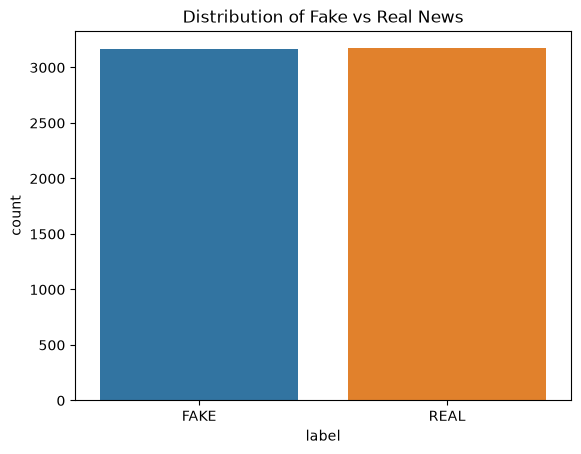

In [5]:
# create count plot for two features
sns.countplot(x="label", data=df_raw, hue="label")

# title
plt.title("Distribution of Fake vs Real News")
plt.show()

## 5. Text Preprocessing

### *5.1. Normalizing Whitespaces*

In [6]:
def normalize_whitespace(value):
    """Convert missing text to an empty string and collapse repeated whitespace."""
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

df_clean = df_raw.copy()

for column in ["title", "text", "label"]:
    df_clean[column] = df_clean[column].apply(normalize_whitespace)

### *5.2. Remap Categorical Labels to 0 and 1*

In [7]:
df_clean["label_normalized"] = df_clean["label"].str.upper()
df_clean["target"] = df_clean["label_normalized"].map({"FAKE": 0, "REAL": 1})

df_clean.head()

,source_index,title,text,label,label_normalized,target
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,FAKE,0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,FAKE,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,REAL,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,FAKE,0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,REAL,1


### *5.3. Removing Duplicates*

In [8]:
print(f"Before dropping duplicates: {df_clean.shape}")
df_clean = df_clean.drop_duplicates(subset=["title"])
print(f"After dropping duplicates: {df_clean.shape}")

df_clean.head()

Before dropping duplicates: (6335, 6)
After dropping duplicates: (6256, 6)


,source_index,title,text,label,label_normalized,target
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,FAKE,0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,FAKE,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,REAL,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,FAKE,0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,REAL,1


## 6. Remove Stop Words

In [9]:
# # download the required data packages
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('punkt_tab')

In [10]:
stop_words = set(stopwords.words("english"))
for col in ["title", "text"]:
    df_clean[col + "_clean"] = df_clean[col].apply(lambda x: ' '.join([word for word in x.lower().split() if word not in stop_words]))

df_clean.head()


,source_index,title,text,label,label_normalized,target,title_clean,text_clean
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,FAKE,0,smell hillary’s fear,"daniel greenfield, shillman journalism fellow ..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,FAKE,0,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,REAL,1,kerry go paris gesture sympathy,u.s. secretary state john f. kerry said monday...
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,FAKE,0,bernie supporters twitter erupt anger dnc: 'we...,"— kaydee king (@kaydeeking) november 9, 2016 l..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,REAL,1,battle new york: primary matters,primary day new york front-runners hillary cli...


## 7. Top Word Visualization

In [11]:
wordcloud_fake = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(' '.join(df_clean.loc[df_clean['target'] == 0, 'text_clean']))
wordcloud_real = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(' '.join(df_clean.loc[df_clean['target'] == 1, 'text_clean']))

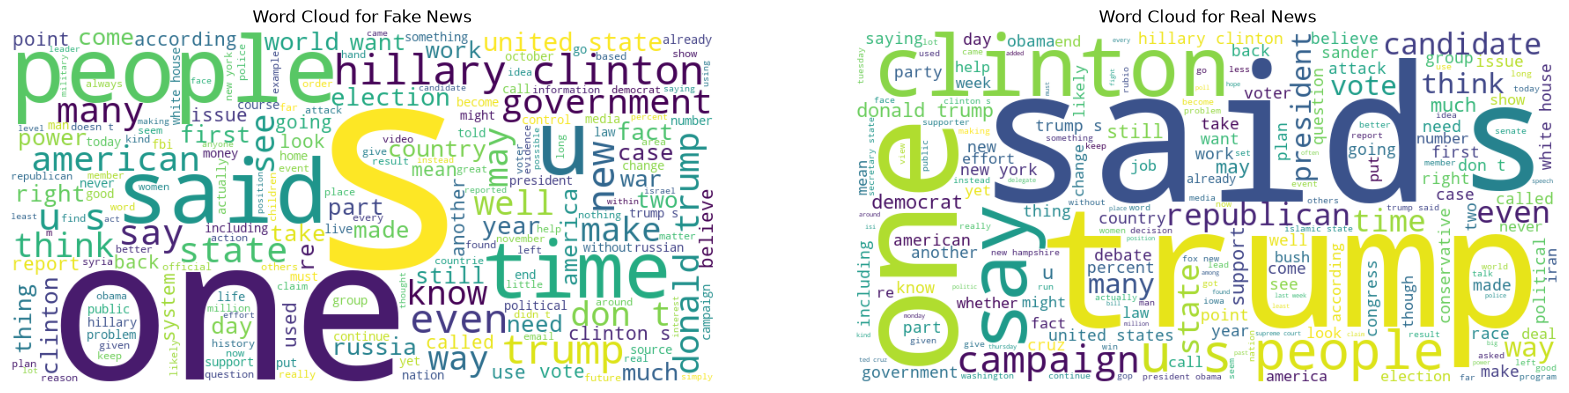

In [12]:
# both fake and real news word clouds side by side
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_fake)
plt.axis("off")  # hide the x and y axis lines/ticks
plt.title("Word Cloud for Fake News")
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_real)
plt.axis("off")  # hide the x and y axis lines/ticks
plt.title("Word Cloud for Real News")
plt.show()

## 8. Label Distribution After Cleaning

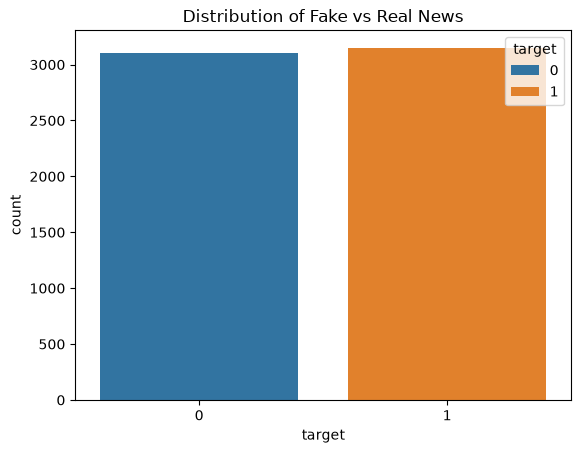

In [16]:
# create count plot for two features
sns.countplot(x="target", data=df_clean, hue="target")

# title
plt.title("Distribution of Fake vs Real News")
plt.show()

## 9. Cleaned Dataset Preview

In [13]:
df_clean.head()

,source_index,title,text,label,label_normalized,target,title_clean,text_clean
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,FAKE,0,smell hillary’s fear,"daniel greenfield, shillman journalism fellow ..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,FAKE,0,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,REAL,1,kerry go paris gesture sympathy,u.s. secretary state john f. kerry said monday...
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,FAKE,0,bernie supporters twitter erupt anger dnc: 'we...,"— kaydee king (@kaydeeking) november 9, 2016 l..."
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,REAL,1,battle new york: primary matters,primary day new york front-runners hillary cli...


In [14]:
df_export = df_clean.drop(columns=["source_index", "title", "text", "label", "label_normalized"])
df_export.head()

,target,title_clean,text_clean
0,0,smell hillary’s fear,"daniel greenfield, shillman journalism fellow ..."
1,0,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...
2,1,kerry go paris gesture sympathy,u.s. secretary state john f. kerry said monday...
3,0,bernie supporters twitter erupt anger dnc: 'we...,"— kaydee king (@kaydeeking) november 9, 2016 l..."
4,1,battle new york: primary matters,primary day new york front-runners hillary cli...


In [15]:
df_export.to_csv("data/cleaned_news.csv", index=False)